Importing the libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.impute import SimpleImputer

from imblearn.over_sampling import RandomOverSampler

import joblib

Load Dataset

In [ ]:
df = pd.read_csv("/content/sample_data/weatherHistory.csv")

print(df.shape)
df.head()

(96453, 12)


,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


Missing values check

In [ ]:
df.isnull().sum()

,0
Formatted Date,0
Summary,0
Precip Type,517
Temperature (C),0
Apparent Temperature (C),0
Humidity,0
Wind Speed (km/h),0
Wind Bearing (degrees),0
Visibility (km),0
Loud Cover,0


Data cleaning

In [ ]:
df['Precip Type'] = df['Precip Type'].fillna('none')
df = df.drop_duplicates()

df['Formatted Date'] = pd.to_datetime(df['Formatted Date'], utc=True)
df['Hour'] = df['Formatted Date'].dt.hour


simplify weather labels

In [ ]:
def simplify_weather(summary):
    s = summary.lower()
    if any(x in s for x in ['rain', 'drizzle', 'snow']):
        return 'Rain'
    elif 'fog' in s:
        return 'Fog'
    elif 'cloud' in s or 'overcast' in s:
        return 'Cloudy'
    elif 'clear' in s or 'dry' in s:
        return 'Clear'
    else:
        return 'Cloudy'

df['Weather_Summary'] = df['Summary'].apply(simplify_weather)


Encode target

In [ ]:
le = LabelEncoder()
df['Summary_Label'] = le.fit_transform(df['Weather_Summary'])

df['Weather_Summary'].value_counts()


,count
Weather_Summary,
Cloudy,78221
Clear,10909
Fog,7187
Rain,112


Class distribution graph

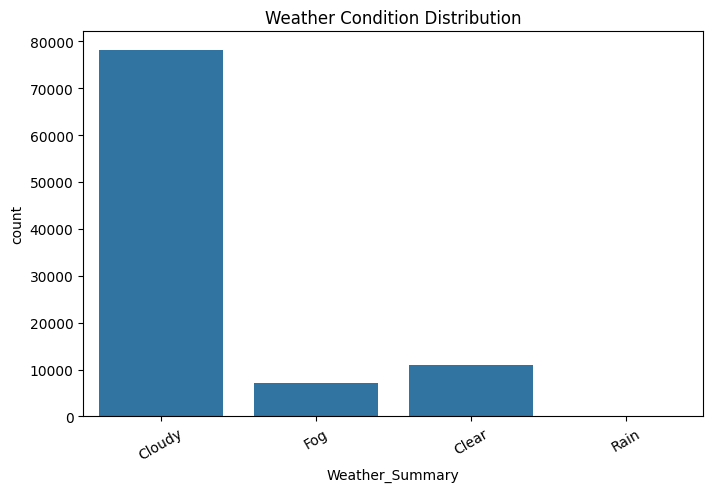

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x=df['Weather_Summary'])
plt.title("Weather Condition Distribution")
plt.xticks(rotation=30)
plt.show()


Feature selection

In [ ]:
df['Precip_Enc'] = df['Precip Type'].map({'none':0, 'rain':1, 'snow':2})

df['Temp_Humidity'] = df['Temperature (C)'] * df['Humidity']

features = [
    'Temperature (C)',
    'Humidity',
    'Wind Speed (km/h)',
    'Pressure (millibars)',
    'Visibility (km)',
    'Hour',
    'Precip_Enc',
    'Temp_Humidity'
]

X = df[features]
y = df['Summary_Label']


Imputation

In [ ]:
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)


Train test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Handle class imbalance

In [ ]:
ros = RandomOverSampler(random_state=42)
X_train, y_train = ros.fit_resample(X_train, y_train)

train Random Forest

In [ ]:
model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

model.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', n_estimators=300, n_jobs=-1,
                       random_state=42)

Model evaluation

In [ ]:
pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred, target_names=le.classes_))


Accuracy: 0.8966607902105154
              precision    recall  f1-score   support

       Clear       0.59      0.31      0.41      2182
      Cloudy       0.91      0.97      0.94     15644
         Fog       0.99      1.00      1.00      1438
        Rain       1.00      0.27      0.43        22

    accuracy                           0.90     19286
   macro avg       0.87      0.64      0.69     19286
weighted avg       0.88      0.90      0.88     19286



Confusion matrix

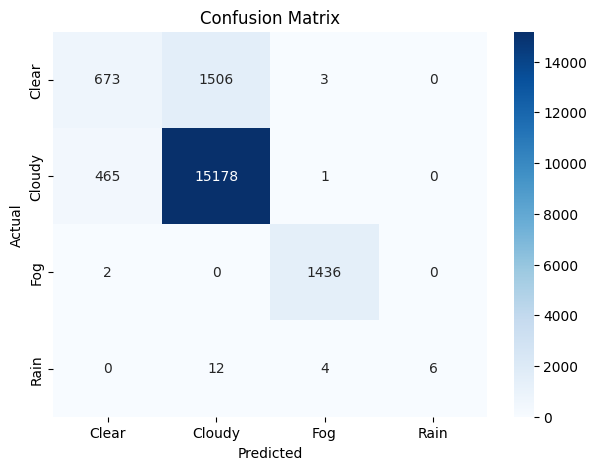

In [ ]:
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


Feature importance

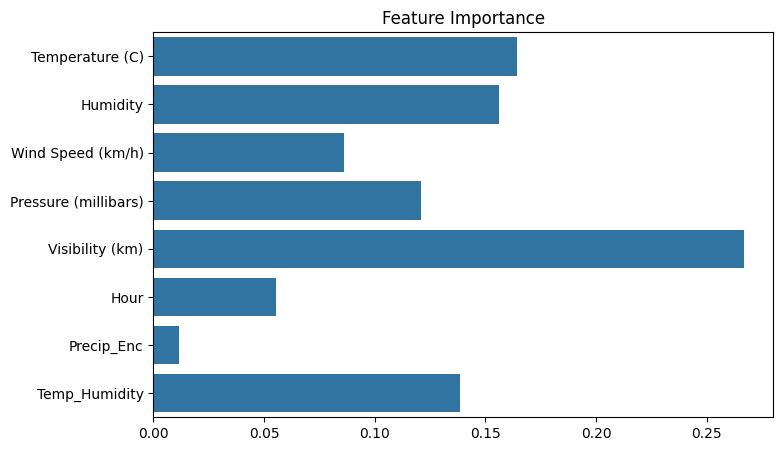

In [ ]:
importances = model.feature_importances_

plt.figure(figsize=(8,5))
sns.barplot(x=importances, y=features)
plt.title("Feature Importance")
plt.show()


Saving Model

In [ ]:
joblib.dump(model, "weather_summary_model.pkl")
joblib.dump(le, "label_encoder.pkl")

print("Model and encoder saved!")


Model and encoder saved!
